In [4]:
from langchain_openai import ChatOpenAI
from langchain.messages import HumanMessage,SystemMessage
from langchain_core.prompts import ChatPromptTemplate,PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_community.document_loaders import DirectoryLoader,PyPDFLoader,WikipediaLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma, FAISS
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langgraph.graph import StateGraph,START, END,MessagesState
from typing import TypedDict,Annotated,Literal
import os 
import sys
from langchain_core.tools import tool
sys.path.insert(1, r'D:\Notebooks\LLM\env')
from enviorment import load_env
import os 
load_env()
from langchain_community.tools.tavily_search import TavilySearchResults

from langgraph_supervisor import create_supervisor
from langchain.agents import create_agent


In [2]:
from langchain_community.document_loaders import WikipediaLoader

In [27]:
FORBIDDEN_KEYWORDS = {
    "403 forbidden", "access denied", "captcha",
    "has been denied", "not authorized", "verify you are a human"
}
@tool
def web_search(query):
    """
    General-purpose web search.

    Use when you need recent or broader information from the web to answer the user's request
    (e.g., discover relevant entities, find supporting context, or gather up-to-date references).

    Parameters:
    - query (str): The search query in plain language.
    - max_results (int): Number of results to return (default 5, max 10).

    Returns:
    - {"results": [{"title": str, "url": str, "snippet": str}, ...]}

    Example:
    - query: "emerging AI hardware companies"
    """
    search = TavilySearchResults(max_results=2)
    res=search.invoke({"query": query})
    s=[]
    for i in res:
        s.append(i['content'])
    l=' '.join(s)
    results=l

    return {"results": l}

In [ ]:
# s=web_search.invoke("what is AI")
# s

{'results': 'Google Gemini image generation controversy\n   Pause Giant AI Experiments\n   Removal of Sam Altman from OpenAI\n   Statement on AI Risk\n   Tay (chatbot) "Tay (chatbot)")\n   _Théâtre D\'opéra Spatial_\n   Voiceverse NFT plagiarism scandal\nGlossary\n\n   Glossary\n   v\n   t\n   e\n\nArtificial intelligence (AI) is the capability of computational systems to perform tasks typically associated with human intelligence, such as learning, reasoning, problem-solving, perception, and decision-making. It is a field of research in computer science that develops and studies methods and software that enable machines to perceive their environment and use learning and intelligence to take actions that maximize their chances of achieving defined goals.( What it is: AI is a field of computer science focused on creating smart machines that can perform tasks that typically require human intelligence, like learning, reasoning, and problem-solving.\n How it works: AI systems learn from vas

In [29]:
@tool
def wiki_search(topic: str, max_results: int = 5) -> dict:
    """
    Fetch a concise encyclopedic summary for a single entity or topic.

    When to use:
      - You need neutral background about a company, product, person, or concept.

    How to format `topic` (VERY IMPORTANT):
      - Pass a short, Wikipedia-friendly title or entity name.
      - Avoid questions or long queries. Prefer canonical forms.
      - If you have noisy text, reduce it to the key noun phrase.

    Good examples:
      - "NVIDIA", "OpenAI", "Large language model", "Electric vehicle"
    Avoid:
      - "What is NVIDIA and why is it important?", "tell me about AI chips 2025"

    Parameters:
      - topic (str): Canonical page title or concise entity/topic.
    """
    max_results = max(1, min(max_results, 10))
    wiki = WikipediaLoader(query=topic, load_max_docs=max_results)
    raw = wiki.load()

    results = [
      {
        "title": doc.metadata["title"],
        "summary": doc.metadata["summary"],
        "source": doc.metadata["source"]
      }
      for doc in raw
    ]

    return {"results": results}

In [37]:
eval(pformat({"cool":'123'}))

{'cool': '123'}

In [38]:
import requests
from pprint import pformat
from datetime import datetime
import yfinance as yf
import uuid
_GLOBAL_STORE = None
from langchain_core.runnables import RunnableConfig

# def initialize_store(store):
#     global _GLOBAL_STORE
#     _GLOBAL_STORE = store

# def get_global_store():
#     return _GLOBAL_STORE
@tool("lookup_stock")
def lookup_stock_symbol(company_name: str) -> str:
    """
    Converts a company name to its stock symbol using a financial API.

    Parameters:
        company_name (str): The full company name (e.g., 'Tesla').

    Returns:
        str: The stock symbol (e.g., 'TSLA') or an error message.
    """
    api_url = "https://www.alphavantage.co/query"
    params = {
        "function": "SYMBOL_SEARCH",
        "keywords": company_name,
        "apikey": "C9PE94QUEW9VWGFM"
    }
    
    response = requests.get(api_url, params=params)
    data = response.json()
    
    if "bestMatches" in data and data["bestMatches"]:
        return data["bestMatches"][0]["1. symbol"]
    else:
        return f"Symbol not found for {company_name}."


@tool("fetch_stock_data")
def fetch_stock_data_raw(stock_symbol: str) -> dict:
    """
    Fetches comprehensive stock data for a given symbol and returns it as a combined dictionary.

    Parameters:
        stock_symbol (str): The stock ticker symbol (e.g., 'TSLA').
        period (str): The period to analyze (e.g., '1mo', '3mo', '1y').

    Returns:
        dict: A dictionary combining general stock info and historical market data.
    """
    period = "1mo"
    try:
        stock = yf.Ticker(stock_symbol)

        # Retrieve general stock info and historical market data
        stock_info = stock.info  # Basic company and stock data
        stock_history = stock.history(period=period).to_dict()  # Historical OHLCV data

        # Combine both into a single dictionary
        combined_data = {
            "stock_symbol": stock_symbol,
            "info": stock_info,
            "history": stock_history
        }

        return pformat(combined_data)

    except Exception as e:
        return {"error": f"Error fetching stock data for {stock_symbol}: {str(e)}"}


@tool
def place_order(
    symbol: str,
    action: str,
    shares: int,
    limit_price: float,
    order_type: str = "limit",
) -> dict:
    """
    Execute a stock order.

    Parameters:
    - symbol: Ticker
    - action: "buy" or "sell"
    - shares: Number of shares to trade (pre-computed by the agent)
    - limit_price: Limit price per share
    - order_type: Order type, default "limit"

    Returns:
    - status: Execution result (simulated)
    - symbol
    - shares
    - limit_price
    - total_spent
    - type: Order type used
    - action
    """
    total_spent = round(int(shares) * limit_price, 2)
    return {
        "status": "filled",
        "symbol": symbol,
        "shares": int(shares),
        "limit_price": limit_price,
        "total_spent": total_spent,
        "type": order_type,
        "action": action,
    }


@tool
def current_timestamp() -> dict:
    """
    Return the current local timestamp.

    Returns:
    - {"iso": str, "epoch": int, "tz": str}
      where:
      - iso: ISO 8601 string with timezone offset
      - epoch: Unix epoch seconds
      - tz: timezone name/offset
    """
    now = datetime.now().astimezone()
    return {
        "iso": now.isoformat(),
        "epoch": int(now.timestamp()),
        "tz": str(now.tzinfo),
    }


# @tool
# def get_order_history(config: RunnableConfig) -> list:
#     """
#     Retrieves past investment orders for the current user.
    
#     Returns:
#         A list of past orders with details including order_id, timestamp, symbol, shares, and price
        
#     Example Usage: 
#         Review previous investments before recommending new ones
#     """
#     user_id = config["configurable"].get("user_id")
#     namespace = ("ledger", user_id)
#     store = get_global_store()
#     items = store.search(namespace)
#     return [item.value for item in items]
    

@tool
def add_order_to_history(symbol: str, shares: int, price: float, config: RunnableConfig) -> dict:
    """
    Records a new investment order in the user's order history.
    
    Args:
        symbol: Stock ticker symbol (e.g., 'AAPL', 'MSFT')
        shares: Number of shares purchased or sold (positive for buy, negative for sell)
        price: Price per share in USD
        
    Returns:
        Dictionary containing the newly created order details including order_id and timestamp
        
    Example:
        To record a purchase of 10 shares of Apple at $190.50:
        add_order_to_history(symbol='AAPL', shares=10, price=190.50)
    """
    user_id = config["configurable"].get("user_id")
    namespace = ("ledger", user_id)
    #store = get_global_store()

    order_id = str(uuid.uuid4())
    order = {
        "order_id": order_id,
        "ts": datetime.now().isoformat(),
        "symbol": symbol,
        "shares": shares,
        "price": price
    }
    #store.put(namespace, order_id, order)

    return order

In [39]:
model=ChatOpenAI()

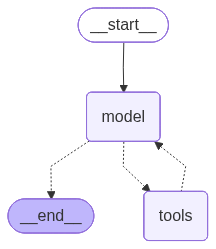

In [42]:
from langgraph.prebuilt import create_react_agent
from pydantic import BaseModel, Field
#from IPython.display import Image, display

RESEARCH_SYSTEM_MESSAGE = """
You are a Research Agent that recommends ONE promising company for investment based on user requests.

Find a company that matches the user's theme/sector. Use tools to verify information. Be factual and concise.

Rules:
- Recommend exactly ONE company that is publicly tradable
- **Important!** ensure that the company you recommend is is publicly tradable!
- Make 2-3 tool calls maximum
- Don't place trades or fabricate data
- End with: CHOSEN_COMPANY: <Company Name>

Output a 1-2 sentence explanation followed by the company name.
"""

research = create_agent(
    model=model,
    tools=[web_search, wiki_search],
    system_prompt=RESEARCH_SYSTEM_MESSAGE,

    name="research"
)

research

In [ ]:
from langgraph.prebuilt import create_react_agent
from IPython.display import Image, display

PORTFOLIO_SYSTEM_MESSAGE = """
You are a financial advisor that executes trades. Use tools to get market data and place orders.

Rules:
- Only execute trades for the EXACT company recommended by the research agent
- If the recommended company is not available for trading, report back without substituting alternatives
- Include specific parameters in your actions (symbol, shares, price)
- Use factual data, never fabricate information
- Do not make assumptions about alternative investments if the requested one is unavailable
- Maintain complete records of all successful trades for future reference and analysis
- NEVER provide any details of user's portfoliosummaries, if there is a request for report, only provide datas that might help building it and pass!
"""

portfolio = create_agent(
    model="openai:gpt-4o-mini",
    tools=[lookup_stock_symbol, fetch_stock_data_raw, place_order, add_order_to_history],
    prompt=PORTFOLIO_SYSTEM_MESSAGE,
   # store=get_global_store(),
    name="portfolio"
)